In [4]:
import re
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from analyses.plotting.scatter_with_regression import \
    plot_scatter_with_regression
from analyses.utils.aggregate_data import aggregate_data
from processing.avo import (correct_pnc_using_dynamic_cutoff,
                            correlate_pnc_pm10,
                            extract_detailed_data_zip_to_polars_dfs)


def _wavelength_to_color(wavelengths):
    norm = mcolors.Normalize(vmin=min(wavelengths), vmax=max(wavelengths))
    colormap = cm.get_cmap("rainbow")
    return [mcolors.to_hex(colormap(norm(w))) for w in wavelengths]

def plot_time_series(
    df: pl.DataFrame,
    channels_and_colors: dict,
    highlight_channel: str = None,
    dtm: str = "dtm",
    output_path: Path = Path("ae31_plot.png"),
    figsize: tuple = (10, 5),
    title: str = "Aethalometer AE31 hourly data (Dagoretti Corner, NRB)",
    xlabel: str = "Date",
    ylabel: str | tuple[str] | None = "ylabel",
    legend_title: str = "Channels",
    legend_loc: str = "upper right",
    legend_fontsize: int = 8,
    plot_type: str = "line",  # Options: "line" or "scatter"
    which_y_axes: tuple[int] | None = None,  # 1 = left, 2 = right
    grid: bool = False,  # Enable or disable grid
):
    assert plot_type in {"line", "scatter"}, "plot_type must be 'line' or 'scatter'"

    df_pd = df.to_pandas()
    x = df_pd[dtm]

    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    # Set y-axis labels
    if isinstance(ylabel, list) and len(ylabel) == 2:
        ax1.set_ylabel(ylabel[0])
        ax2.set_ylabel(ylabel[1])
    elif isinstance(ylabel, str):
        ax1.set_ylabel(ylabel)
    elif ylabel is not None:
        raise ValueError("ylabel must be a string, a list of two strings, or None")

    # Assign all channels to axis 1 by default
    if which_y_axes is None:
        which_y_axes = [1] * len(channels_and_colors)

    if len(which_y_axes) != len(channels_and_colors):
        raise ValueError("Length of which_y_axes must match number of channels.")

    # Map channels to their axis
    ch_axis = dict(zip(channels_and_colors.keys(), which_y_axes))

    for ch, color in channels_and_colors.items():
        y = df_pd[ch]
        ax = ax1 if ch_axis[ch] == 1 else ax2

        if ch == highlight_channel:
            ax.scatter(x, y, color=color, label=ch, s=10, zorder=5)
        else:
            if plot_type == "scatter":
                ax.scatter(x, y, color=color, label=ch, s=8)
            else:
                ax.plot(x, y, color=color, label=ch, linewidth=1.0)

    ax1.set_title(title)
    ax1.set_xlabel(xlabel)

    # Grid control
    ax1.grid(grid)
    ax2.grid(False)

    # Enable horizontal (x-axis) tick marks
    ax1.tick_params(axis='x', which='both', direction='out', bottom=True, top=False, length=4)
    ax2.tick_params(axis='x', which='both', direction='out', bottom=True, top=False, length=4)

    # Merge and display legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        title=legend_title,
        loc=legend_loc,
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
    )

    fig.autofmt_xdate()
    fig.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

    print(f"✅ Time series {plot_type} plot saved to {output_path}")    

def plot_diurnal_by_wavelength(
    df: pl.DataFrame,
    channels_and_colors: dict,
    dtm: str = "dtm",
    plot_type: str = "box",  # Options: "box", "violin", "swarm"
    output_path: Path = Path("ae31_diurnal.png"),
    figsize: tuple = (10, 5),
    title: str = "Diurnal variability of aerosol absorption (Dagoretti Corner, NRB)",
    xlabel: str = "Hour of Day [UTC]",
    ylabel: str = "Equivalent black carbon (BC) concentration (ng/m³)",
    legend_title: str = "Channels",
    legend_loc: str = "upper right",
    legend_fontsize: int = 8,
):
    assert plot_type in {"box", "violin", "swarm"}, "plot_type must be 'box', 'violin', or 'swarm'"

    # 1. Add hour column
    df = df.with_columns(
        pl.col(dtm).dt.hour().alias("hour")
    )

    # 2. Melt to long format
    melted = df.melt(
        id_vars=["hour"],
        value_vars=list(channels_and_colors.keys()),
        variable_name="channel",
        value_name="value"
    )

    # 3. Filter negative values
    melted = melted.filter(pl.col("value") >= 0)

    # 4. Convert to pandas for Seaborn
    df_plot = melted.to_pandas()

    # 5. Ensure channel order by wavelength
    channel_order = list(channels_and_colors.keys())

    # 6. Plot
    plt.figure(figsize=figsize)
    ax = plt.gca()

    if plot_type == "box":
        sns.boxplot(
            data=df_plot,
            x="hour", y="value", hue="channel",
            hue_order=channel_order,
            palette=channels_and_colors,
            width=0.7,
            fliersize=2,
            ax=ax,
        )
    elif plot_type == "violin":
        sns.violinplot(
            data=df_plot,
            x="hour", y="value", hue="channel",
            hue_order=channel_order,
            palette=channels_and_colors,
            linewidth=0.8,
            ax=ax,
        )
    elif plot_type == "swarm":
        sns.swarmplot(
            data=df_plot,
            x="hour", y="value", hue="channel",
            hue_order=channel_order,
            palette=channels_and_colors,
            size=2,
            ax=ax,
        )

    # Final touches
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Legend
    ax.legend(
        title=legend_title,
        loc=legend_loc,
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

    print(f"✅ Diurnal {plot_type} plot saved to {output_path}")

def combine_avo_fidas_pm_dataframes(df_avo: pl.DataFrame, df_fidas: pl.DataFrame) -> pl.DataFrame:
    """
    Aligns and merges AVO and FIDAS data for PM1, PM2.5, PM10, and PNC based on common timestamps.
    Converts FIDAS PM values from mg/m³ to µg/m³.
    Adds '_avo [unit]' and '_fidas [unit]' suffixes to columns.

    Args:
        df_avo (pl.DataFrame): AVO dataframe with 'dtm' and PMx [ug/m3] and PNC [1/cm³].
        df_fidas (pl.DataFrame): FIDAS dataframe with 'dtm', PMx [mg/m³], and PNC [1/cm³].

    Returns:
        pl.DataFrame: Joined dataframe with renamed columns and aligned timestamps.
    """
    pm_vars = ["PM1", "PM2.5", "PM10"]
    pnc_var = "PNC"
    unit_pm = " [µg/m3]"
    unit_pnc = " [1/cm³]"

    # Ensure naive timestamps
    df_avo = df_avo.with_columns(pl.col("dtm").dt.replace_time_zone(None))
    df_fidas = df_fidas.with_columns(pl.col("dtm").dt.replace_time_zone(None))

    # --- AVO columns: PM + PNC ---
    avo_cols = ["dtm"]
    avo_renames = {}

    for pm in pm_vars:
        src_col = f"{pm} [ug/m3]"
        dst_col = f"{pm}_avo{unit_pm}"
        if src_col in df_avo.columns:
            avo_cols.append(src_col)
            avo_renames[src_col] = dst_col

    src_col = f"{pnc_var} [1/cm3]"
    dst_col = f"{pnc_var}_avo{unit_pnc}"
    if src_col in df_avo.columns:
        avo_cols.append(src_col)
        avo_renames[src_col] = dst_col

    df_avo = df_avo.select(avo_cols).rename(avo_renames)

    # --- FIDAS columns: PM (convert) + PNC ---
    fidas_cols = ["dtm"]
    fidas_renames = {}
    conversions = []

    for pm in pm_vars:
        src_col = f"{pm} [mg/m³]"
        dst_col = f"{pm}_fidas{unit_pm}"
        if src_col in df_fidas.columns:
            fidas_cols.append(src_col)
            fidas_renames[src_col] = dst_col
            conversions.append((src_col, dst_col))  # needs ×1000

    src_col = f"{pnc_var} [1/cm³]"
    dst_col = f"{pnc_var}_fidas{unit_pnc}"
    if src_col in df_fidas.columns:
        fidas_cols.append(src_col)
        fidas_renames[src_col] = dst_col

    # Select only the columns we'll convert or rename
    df_fidas = df_fidas.select(fidas_cols)

    # Apply conversion and renaming in one step for converted columns
    converted = [(pl.col(src) * 1000).alias(dst) for src, dst in conversions]

    # Add direct renames for PNC (no conversion)
    direct_renames = [pl.col(src).alias(dst) for src, dst in fidas_renames.items() if src not in dict(conversions)]

    # Build clean dataframe
    df_fidas = df_fidas.select(["dtm"] + converted + direct_renames)

    # Align on common timestamps
    dt_common = pl.Series("dtm", np.intersect1d(
        df_avo["dtm"].to_numpy(),
        df_fidas["dtm"].to_numpy()
    ))

    df_avo = df_avo.filter(pl.col("dtm").is_in(dt_common)).sort("dtm")
    df_fidas = df_fidas.filter(pl.col("dtm").is_in(dt_common)).sort("dtm")

    return df_avo.join(df_fidas, on="dtm")

def plot_pm_comparison_from_dataframe(df: pl.DataFrame,
                                      output_dir: Path,
                                      width: float = 6,
                                      height: float = 5) -> None:
    """
    Generate scatter + regression plots for PM1, PM2.5, PM10, and PNC from a joined dataframe.
    Adds dashed 1:1 line and uses equal axis limits.

    Args:
        df (pl.DataFrame): Must contain 'VAR_avo [unit]' and 'VAR_fidas [unit]' columns.
        output_dir (Path): Directory to save plots.
        width (float): Plot width in inches.
        height (float): Plot height in inches.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    vars_to_plot = [
        ("PM1", " [µg/m3]"),
        ("PM2.5", " [µg/m3]"),
        ("PM10", " [µg/m3]"),
        ("PNC", " [1/cm³]"),
    ]

    for var, unit in vars_to_plot:
        avo_col = f"{var}_avo{unit}"
        fidas_col = f"{var}_fidas{unit}"

        if avo_col not in df.columns or fidas_col not in df.columns:
            print(f"⚠️ Columns missing for {var}")
            continue

        df_pair = df.select([avo_col, fidas_col]).drop_nulls()
        x = df_pair[fidas_col].to_numpy()
        y = df_pair[avo_col].to_numpy()

        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
            print(f"⚠️ Skipping {var}: insufficient or invalid data (n={len(x)})")
            continue

        slope, intercept = np.polyfit(x, y, 1)
        r = np.corrcoef(x, y)[0, 1]

        lim_min = min(x.min(), y.min())
        lim_max = max(x.max(), y.max())
        padding = 0.05 * (lim_max - lim_min)
        lim_min -= padding
        lim_max += padding

        plt.figure(figsize=(width, height))
        plt.scatter(x, y, alpha=0.5, label="Data")
        x_fit = np.linspace(lim_min, lim_max, 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color="black", lw=2, label="Fit")
        plt.plot(x_fit, x_fit, linestyle="--", color="red", label="1:1 line")

        plt.xlabel(f"FIDAS {var}{unit}")
        plt.ylabel(f"AVO {var}{unit}")
        plt.title(f"{var} comparison")
        plt.text(0.05, 0.95,
                 f"$r$ = {r:.3f}\n$y = {slope:.2f}x + {intercept:.2f}$",
                 transform=plt.gca().transAxes,
                 fontsize=10, va='top', ha='left',
                 bbox=dict(facecolor='white', alpha=0.7))
        plt.grid(True)
        plt.legend()
        plt.xlim(lim_min, lim_max)
        plt.ylim(lim_min, lim_max)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.tight_layout()

        plot_filename = output_dir / f"nrb_avo_fidas_{var.replace('.', '')}.png"
        plt.savefig(plot_filename, dpi=150)
        plt.close()

def combine_ae31_fidas_dataframes(ae31_path: Path, fidas_path: Path, output_path: Path = Path("ae31_fidas.parquet")) -> pl.DataFrame:
    df_ae31 = pl.read_parquet(ae31_path)
    df_fidas = pl.read_parquet(fidas_path)

    # Rename and convert units
    if "IR880" in df_ae31.columns:
        df_ae31 = df_ae31.with_columns((pl.col("IR880") / 1000).cast(pl.Float32).alias("BC [µg/m3]"))
    if "PMtotal [mg/m³]" in df_fidas.columns:
        df_fidas = df_fidas.with_columns((pl.col("PMtotal [mg/m³]") * 1000).cast(pl.Float32).alias("PM total [µg/m3]"))

    # Join on dtm
    df = df_ae31.join(df_fidas, on="dtm", how="inner")
    df = _insert_missing_datetimes(df=df)
    df.write_parquet(output_path)
    return df
    
def plot_ae31_bc_fidas_pm_timeseries(df: pl.DataFrame, output_path: Path = Path("ae31_fidas_timeseries.png")):    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(df["dtm"].to_numpy(), df["BC [µg/m3]"].to_numpy(), label="BC [µg/m3] (from AE31)", color="black")
    plt.plot(df["dtm"].to_numpy(), df["PM total [µg/m3]"].to_numpy(), label="PM total [µg/m3] (from Fidas)", color="red")
    plt.xlabel("Date")
    plt.ylabel("Total PM, Equivalent BC (µg/m³)")
    plt.title("Total Particulate Matter & Equivalent Black Carbon (BC), hourly values (Dagoretti Corner, NRB)")
    plt.legend()
    plt.grid(False)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

    print(f"✅ Saved plot to {output_path}")

def _insert_missing_datetimes(df: pl.DataFrame, dtm: str = "dtm", freq: str = "1h") -> pl.DataFrame:
    """
    Inserts missing datetime entries into the dataframe, filling other columns with nulls.

    Args:
        df (pl.DataFrame): The input dataframe.
        dtm (str): Name of the datetime column.
        freq (str): Frequency string, e.g. "1h" for hourly.

    Returns:
        pl.DataFrame: A new dataframe with missing datetime entries filled and nulls in other columns.
    """
    # Ensure dtm column is sorted and unique
    df = df.sort(dtm).unique(subset=[dtm])

    # Determine the full datetime range
    start = df[dtm][0]
    end = df[dtm][-1]
    full_range = pl.select([
        pl.datetime_range(
            start=start,
            end=end,
            interval=freq,
            time_unit="us",
            time_zone="UTC"
        ).alias(dtm)
    ])

    # Join full range with original dataframe
    df_full = full_range.join(df, on=dtm, how="left")

    return df_full

import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
from pathlib import Path


def plot_ae31_bc_fidas_pm_scatter(
    df: pl.DataFrame,
    bc_col: str = "BC [µg/m3]",
    pm_col: str = "PM total [µg/m3]",
    output_path: Path = Path("bc_vs_pm_scatter.png")
):
    """
    Create a scatter plot of BC vs PM with linear regression line and R².

    Args:
        df (pl.DataFrame): Input data.
        bc_col (str): Column name for black carbon (y-axis).
        pm_col (str): Column name for particulate matter (x-axis).
        output_path (Path): File path to save the plot.
    """
    # Drop nulls and NaNs
    df = df.drop_nulls([bc_col, pm_col])
    df = df.filter((~pl.col(bc_col).is_nan()) & (~pl.col(pm_col).is_nan()))

    # Convert to NumPy arrays
    x = df[pm_col].to_numpy().reshape(-1, 1)
    y = df[bc_col].to_numpy()

    # Fit linear regression
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    # Compute R²
    r2 = r2_score(y, y_pred)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=10, alpha=0.6, label="Data")
    plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}\nR² = {r2:.2f}")

    plt.xlabel("PM total [µg/m3]")
    plt.ylabel("BC [µg/m3]")
    plt.title("Black Carbon vs. Total PM (Hourly Averages)")
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

    print(f"✅ Saved scatter plot with regression to {output_path}")


source = Path("data/level1/nrb")       # folder with .parquet files
target = Path("data/level2/nrb")      # where output should go
results = Path("results") / "aq_conference_nairobi_2025"

In [2]:
########################################################
# Read iQAir AirVisualOutdoor data downloaded manually #
########################################################
path = target / "avo/IQAir_Export_validated_devices_30Jun23-30Jun24_hourly.zip"
dfs1 = extract_detailed_data_zip_to_polars_dfs(Path(path))
path = target / "avo/IQAir_Export_validated_devices_29Jun24-29Jun25_hourly.zip"
dfs2 = extract_detailed_data_zip_to_polars_dfs(Path(path))
print(dfs1.keys())  # -> Source IDs
print(dfs2.keys())  # -> Source IDs

df_avo_nrb = pl.concat([dfs1['x15ai15feje'], dfs2['x15ai15feje']], how="diagonal").sort("dtm")
df_avo_nrb.write_parquet(target / "avo/df_avo_nrb-hourly.parquet")
# df_avo_bmt = pl.concat([dfs1['twrgmdgz53t'], dfs2['twrgmdgz53t']], how="diagonal")
# df_avo_bmt.write_parquet(target / "avo/df_avo_bmt-hourly.parquet")
# df_avo_mtf = pl.concat([dfs1['wichuo199fk'], dfs2['wichuo199fk']], how="diagonal")
# df_avo_mtf.write_parquet(target / "avo/df_avo_mtf-hourly.parquet")

display(df_avo_nrb.describe())

# Compute 99th percentile
p99 = df_avo_nrb.select(pl.col("PM10 [ug/m3]").quantile(0.99, "nearest")).item()
print("PM10 99%", p99)
p99 = df_avo_nrb.select(pl.col("PM2.5 [ug/m3]").quantile(0.99, "nearest")).item()
print("PM2.5 99%", p99)

# plot timeseries
channels_and_colors = {
    "PNC [1/cm3]": "#1f77b4",  # Blue       — for number concentration (distinct from mass)
    "PM1 [ug/m3]": "#2ca02c",  # Green      — PM1
    "PM2.5 [ug/m3]": "#ff7f0e",  # Orange     — PM2.5
    # "PM4 [mg/m³]": "#d62728",  # Red        — PM4
    "PM10 [ug/m3]": "#9467bd",  # Purple     — PM10
    # "PMtotal [mg/m³]": "#8c564b",  # Brown      — PMtotal
}

plot_time_series(df_avo_nrb, 
                 channels_and_colors=channels_and_colors, 
                 highlight_channel='PNC [1/cm³]', 
                 plot_type="line", 
                 output_path=results / "nrb_avo_timeseries.png", 
                 figsize=(10, 5),
                 title="iQAir AirVisual Outdoor original hourly data (Dagoretti Corner, NRB)",
                 ylabel=["Aerosol particle mass concentration [µg/m3]", "Aerosol particle number concentration [1/cm3]"],
                 which_y_axes=(2, 1, 1, 1),
                 legend_loc='upper left')


dict_keys(['x15ai15feje'])
dict_keys(['twrgmdgz53t', 'x15ai15feje', 'wichuo199fk'])


statistic,PM2.5 [ug/m3],PM10 [ug/m3],PM1 [ug/m3],CO2 (ppm),T [°C],RH [%],slot.1.pm1,slot.1.pm10,slot.1.pm25,slot.1.no2,slot.2.co2,slot.2.pm1,slot.2.pm10,slot.2.pm25,slot.2.no2,slot.3.co2,slot.3.pm1,slot.3.co,slot.3.no2,slot.4.co2,slot.4.pm1,dtm,P [hPa],PNC [1/cm3]
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",16861.0,16861.0,16861.0,16861.0,16861.0,16861.0,485.0,485.0,485.0,485.0,16379.0,16379.0,16379.0,12367.0,485.0,485.0,485.0,15605.0,15605.0,15605.0,11593.0,"""16861""",16861.0,12367.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,16376.0,16376.0,16376.0,16376.0,482.0,482.0,482.0,4494.0,16376.0,16376.0,16376.0,1256.0,1256.0,1256.0,5268.0,"""0""",0.0,4494.0
"""mean""",14.3036,23.464029,10.271929,418.026274,19.855287,73.383666,11.882474,29.919588,17.373196,412.835052,10.818243,26.295256,15.428537,19104.008814,9.676289,20.418557,13.164948,9.534957,20.282281,12.946427,11931.984646,"""2024-07-11 23:…",840.223059,17.288473
"""std""",13.229476,23.87181,8.408252,24.470455,4.898016,19.476535,4.316579,11.660474,6.562077,8.920772,8.583858,24.070705,13.33573,38488.981224,3.652854,7.855623,5.028597,8.580709,25.054585,13.753961,27112.564937,null,46.738452,35.279515
"""min""",0.0,0.0,0.0,376.0,8.0,16.0,3.0,6.0,4.0,400.0,0.0,0.0,0.0,61.0,2.0,4.0,3.0,0.0,0.0,0.0,49.0,"""2023-07-19 08:…",816.92,0.055
"""25%""",7.0,11.0,5.0,407.0,16.0,57.0,9.0,22.0,13.0,409.0,6.0,12.0,8.0,1081.0,7.0,16.0,10.0,5.0,9.0,6.0,834.0,"""2024-01-18 22:…",822.16,0.974
"""50%""",13.0,21.0,9.0,411.0,18.0,78.0,12.0,30.0,17.0,412.0,10.0,24.0,14.0,1790.0,9.0,20.0,13.0,8.0,17.0,11.0,1344.0,"""2024-07-12 08:…",823.49,1.611
"""75%""",18.0,30.0,13.0,418.0,23.0,90.0,14.0,37.0,22.0,416.0,14.0,35.0,20.0,16906.0,12.0,25.0,16.0,12.0,25.0,17.0,4038.0,"""2025-01-05 03:…",824.88,14.774
"""max""",514.0,1014.0,263.0,809.0,39.0,100.0,31.0,66.0,42.0,478.0,254.0,864.0,457.0,1.047749e6,27.0,55.0,36.0,271.0,1164.0,572.0,873542.0,"""2025-06-29 21:…",978.19,960.646


PM10 99% 94.0
PM2.5 99% 57.0
✅ Time series line plot saved to results/aq_conference_nairobi_2025/nrb_avo_timeseries.png


Applying correction before: 2025-02-12 06:00:00


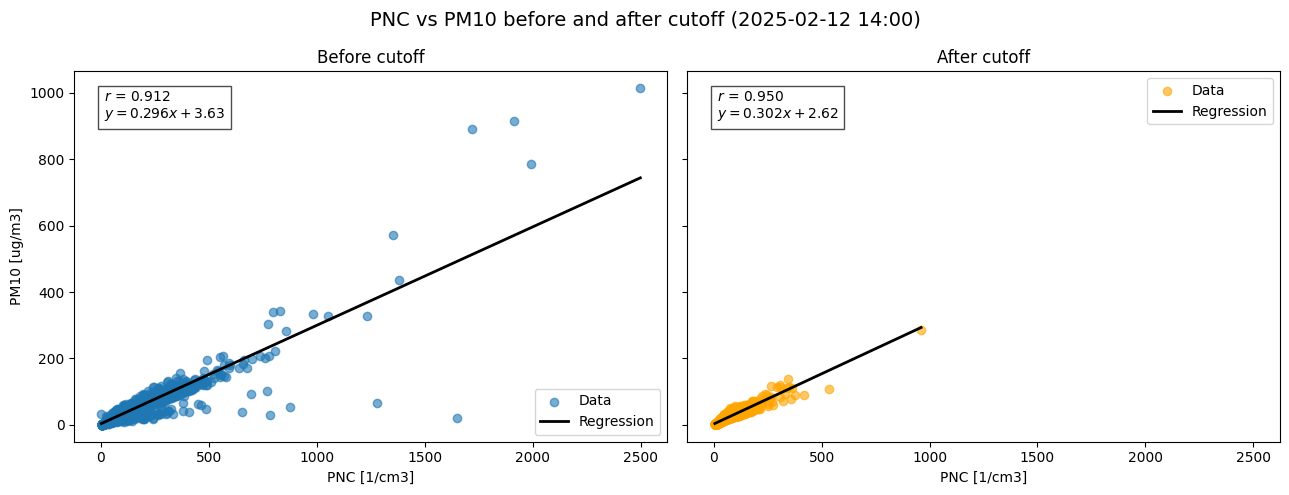

✅ Correlation plot saved to results/aq_conference_nairobi_2025/nrb_avo_corrected_correlate_pnc_pm10.png
✅ Time series line plot saved to results/aq_conference_nairobi_2025/nrb_avo_corrected_timeseries.png


In [5]:
df_avo_nrb_corrected = correct_pnc_using_dynamic_cutoff(df_avo_nrb, pnc_february_level=5, factor=50)
correlate_pnc_pm10(df_avo_nrb_corrected, output_path=results / "nrb_avo_corrected_correlate_pnc_pm10.png")

# plot timeseries
channels_and_colors = {
    "PNC [1/cm3]": "#1f77b4",  # Blue       — for number concentration (distinct from mass)
    "PM1 [ug/m3]": "#2ca02c",  # Green      — PM1
    "PM2.5 [ug/m3]": "#ff7f0e",  # Orange     — PM2.5
    # "PM4 [mg/m³]": "#d62728",  # Red        — PM4
    "PM10 [ug/m3]": "#9467bd",  # Purple     — PM10
    # "PMtotal [mg/m³]": "#8c564b",  # Brown      — PMtotal
}

plot_time_series(df_avo_nrb_corrected, 
                 channels_and_colors=channels_and_colors, 
                 highlight_channel='PNC [1/cm³]', 
                 plot_type="line", 
                 output_path=results / "nrb_avo_corrected_timeseries.png", 
                 figsize=(10, 5),
                 title="iQAir AirVisual Outdoor corrected hourly data (Dagoretti Corner, NRB)",
                 ylabel=["Aerosol particle mass concentration [µg/m3]", "Aerosol particle number concentration [1/cm3]"],
                 which_y_axes=(2, 1, 1, 1),
                 legend_loc='upper left')


In [14]:
######################
# Nairobi Fidas data #
######################
source = Path("data/level1/nrb")       # folder with .parquet files
target = Path("data/level2/nrb")      # where output should go
results = Path("results") / "aq_conference_nairobi_2025"
instrument_name = "fidas"
map = {'60': "PNC [1/cm³]",
        '61': "PM1 [mg/m³]",
        '62': "PM2.5 [mg/m³]",
        '63': "PM4 [mg/m³]",
        '64': "PM10 [mg/m³]",
        '65': "PMtotal [mg/m³]",
}

# aggregate data
df_fidas, file_fidas = aggregate_data(
    source=source,       # folder with .parquet files
    # target=target,      # where output should go
    instrument_name=instrument_name,
    freq="hourly",
    extract_cols=map.keys(),
    statistics="mean",
)
df_fidas = df_fidas.rename({old: new for old, new in map.items() if old in df_fidas.columns})

df_fidas.write_parquet(target / f"nrb_{file_fidas}")

# plot timeseries
channels_and_colors = {
    "PNC [1/cm³]": "#1f77b4",  # Blue       — for number concentration (distinct from mass)
    "PM1 [mg/m³]": "#2ca02c",  # Green      — PM1
    "PM2.5 [mg/m³]": "#ff7f0e",  # Orange     — PM2.5
    "PM4 [mg/m³]": "#d62728",  # Red        — PM4
    "PM10 [mg/m³]": "#9467bd",  # Purple     — PM10
    "PMtotal [mg/m³]": "#8c564b",  # Brown      — PMtotal
}

plot_time_series(df_fidas, 
                 channels_and_colors=channels_and_colors, 
                 highlight_channel="PNC [1/cm³]", 
                 plot_type="line", 
                 output_path=results / "nrb_fidas_timeseries.png", 
                 figsize=(10, 5),
                 title="Fidas hourly data (Dagoretti Corner, NRB)",
                 ylabel=["Aerosol particle mass concentration [mg/m3]", "Aerosol particle number concentration [1/cm3]"],
                 which_y_axes=(2, 1, 1, 1, 1, 1),
                 legend_loc='upper left')


Processing data/level1/nrb/2025/05/fidas.parquet ..
Processing data/level1/nrb/2025/06/fidas.parquet ..
✅ Time series line plot saved to results/aq_conference_nairobi_2025/nrb_fidas_timeseries.png


In [7]:
# Process
df_common = combine_avo_fidas_pm_dataframes(df_avo_nrb, df_fidas)

# Save combined dataframe
df_common.write_parquet(results / "nrb_avo_fidas_combined.parquet")

# Plot
plot_pm_comparison_from_dataframe(df_common, output_dir=results, width=7, height=6)

In [13]:
df_avo_fidas = pl.read_parquet("results/aq_conference_nairobi_2025/nrb_avo_fidas_combined.parquet")
display(df_avo_fidas.describe())

# plot timeseries
channels_and_colors = {
    "PNC_avo [1/cm³]": "#1f77b4",  # Blue       — for number concentration (distinct from mass)
    "PNC_fidas [1/cm³]": "#2ca02c",  # Green      — PM1
    "PM10_avo [µg/m3]": "#d62728",  # Red        — PM10 AVO
    "PM10_fidas [µg/m3]": "#9467bd",  # Purple     — PM10
    # "PMtotal [mg/m³]": "#8c564b",  # Brown      — PMtotal
}

plot_time_series(df_avo_fidas, 
                 channels_and_colors=channels_and_colors, 
                 highlight_channel='PNC_avo [1/cm3]', 
                 plot_type="line", 
                 output_path=results / "nrb_avo_fidas_timeseries.png", 
                 figsize=(10, 5),
                 title="iQAir AirVisual Outdoor vs Fidas hourly data (Dagoretti Corner, NRB)",
                 ylabel=["Equivalent black carbon (BC) concentration [µg/m3]", "Aerosol particle number concentration [1/cm3]"],
                 which_y_axes=(2, 2, 1, 1),
                 legend_loc='upper left')


statistic,dtm,PM1_avo [µg/m3],PM2.5_avo [µg/m3],PM10_avo [µg/m3],PNC_avo [1/cm³],PM1_fidas [µg/m3],PM2.5_fidas [µg/m3],PM10_fidas [µg/m3],PNC_fidas [1/cm³]
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""1161""",1161.0,1161.0,1161.0,1161.0,1161.0,1161.0,1161.0,1161.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2025-05-30 23:…",7.825151,10.604651,17.444444,53.355162,NaN,NaN,NaN,NaN
"""std""",null,5.791604,8.199113,13.875017,48.35586,NaN,NaN,NaN,NaN
"""min""","""2025-05-03 20:…",1.0,1.0,1.0,5.201,0.0,0.0,0.0,0.0
"""25%""","""2025-05-16 08:…",3.0,4.0,6.0,19.524,3.258927,4.17143,5.619642,128.776535
"""50%""","""2025-05-28 10:…",6.0,8.0,14.0,38.065,5.384208,6.818751,9.291964,203.27002
"""75%""","""2025-06-17 19:…",12.0,16.0,25.0,74.341,9.132455,10.964705,14.705555,345.329987
"""max""","""2025-06-29 21:…",57.0,71.0,108.0,536.04,NaN,NaN,NaN,NaN


✅ Time series line plot saved to results/aq_conference_nairobi_2025/nrb_avo_fidas_timeseries.png


In [10]:
#####################
# Nairobi AE31 data #
#####################
instrument_name = "ae31"

# aggregate data
df_ae31, file_ae31 = aggregate_data(
    source=source,       # folder with .parquet files
    # target=target,      # where output should go
    instrument_name=instrument_name,
    freq="hourly",
    statistics="mean"
)
df_ae31.write_parquet(target / f"nrb_{file_ae31}")

# plot timeseries

# Define channels and corresponding wavelengths (in nm)
channels = ["UV370", "B470", "G520", "Y590", "R660", "IR880", "IR950"]
wavelengths = [370, 470, 520, 590, 660, 880, 950]

# Generate colors
colors = _wavelength_to_color(wavelengths)

# Build dictionary
channels_and_colors = dict(zip(channels, colors))

plot_time_series(df_ae31, channels_and_colors, highlight_channel="IR880", output_path=results / "ae31_timeseries.png", figsize=(10, 5), plot_type="scatter")

# plot diurnal variability
plot_diurnal_by_wavelength(df_ae31, channels_and_colors, output_path=results / "ae31_diurnal_cycle_box.png", plot_type="box", figsize=(10, 5))

Processing data/level1/nrb/2024/08/ae31.parquet ..
Processing data/level1/nrb/2024/09/ae31.parquet ..
Processing data/level1/nrb/2024/10/ae31.parquet ..
Processing data/level1/nrb/2024/11/ae31.parquet ..
Processing data/level1/nrb/2024/12/ae31.parquet ..
Processing data/level1/nrb/2025/01/ae31.parquet ..
Processing data/level1/nrb/2025/02/ae31.parquet ..
Processing data/level1/nrb/2025/03/ae31.parquet ..
Processing data/level1/nrb/2025/04/ae31.parquet ..
Processing data/level1/nrb/2025/05/ae31.parquet ..
Processing data/level1/nrb/2025/06/ae31.parquet ..
Processing data/level1/nrb/2025/07/ae31.parquet ..


/tmp/ipykernel_2397749/2614603866.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("rainbow")


✅ Time series scatter plot saved to results/aq_conference_nairobi_2025/ae31_timeseries.png
✅ Diurnal box plot saved to results/aq_conference_nairobi_2025/ae31_diurnal_cycle_box.png


In [5]:
df_ae31_fidas = combine_ae31_fidas_dataframes(ae31_path="data/level2/nrb/nrb_ae31-hourly-mean.parquet",
                                              fidas_path="data/level2/nrb/nrb_fidas-hourly-mean.parquet",
                                              output_path=target / "nrb_ae31_fidas_hourly.parquet")

plot_ae31_bc_fidas_pm_timeseries(df=df_ae31_fidas,
                           output_path=results / "nrb_ae31_bc_fidas_pm_timeseries.png")

plot_ae31_bc_fidas_pm_scatter(df=df_ae31_fidas,
                              output_path=results / "nrb_ae31_bc_fidas_pm_scatter.png")

✅ Saved plot to results/aq_conference_nairobi_2025/nrb_ae31_bc_fidas_pm_timeseries.png
✅ Saved scatter plot with regression to results/aq_conference_nairobi_2025/nrb_ae31_bc_fidas_pm_scatter.png
